# 05 - Classificazione rifiuti con CNN e Transfer Learning

In questo progetto costruiamo un sistema di **image classification multiclass** sul dataset **TrashNet**
per riconoscere 6 categorie di rifiuti:

- cardboard
- glass
- metal
- paper
- plastic
- trash

Obiettivi del progetto:

- Accuracy > `85%`
- Macro F1-score > `0.82`

Strategia modellistica:

1. EDA sul dataset originale
2. preprocessing con resize a `224x224x3`
3. training di 3 modelli di complessita' crescente
4. selezione del miglior modello sulla validation macro F1
5. evaluation finale, error analysis e funzione di deployment

## Ambiente consigliato

Questo notebook e' stato preparato per il kernel Jupyter:

- `py313-global-cifar`
- Python `3.13`
- TensorFlow `2.21`

Nel repository esiste anche `.venv`, utile per tooling e generazione notebook, ma **non** contiene TensorFlow.
Se vuoi creare un ambiente dedicato per questo esercizio, puoi usare questi comandi:

```powershell
py -3.13 -m venv .venv-tf313
.\.venv-tf313\Scripts\Activate.ps1
python -m pip install --upgrade pip
python -m pip install tensorflow matplotlib pandas scikit-learn seaborn pillow ipykernel h5py
python -m ipykernel install --user --name py313-rifiuti --display-name "Python 3.13 (TrashNet)"
```

Nota:

- il ramo **VGG16** puo' richiedere il download iniziale dei pesi ImageNet se non sono gia' presenti in cache locale
- su CPU il training completo puo' richiedere diversi minuti

In [1]:
import json
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from IPython.display import display
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import callbacks, layers, models, optimizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import img_to_array, load_img, to_categorical

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.get_logger().setLevel("ERROR")

ROOT = Path.cwd()
DATASET_DIR = ROOT / "classificazione_rifiuti" / "Garbage classification" / "Garbage classification"
ARTIFACTS_DIR = ROOT / "artifacts" / "05_classificazione_rifiuti"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)
BATCH_SIZE = 32
TARGET_ACCURACY = 0.85
TARGET_MACRO_F1 = 0.82
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Dataset non trovato: {DATASET_DIR}")

CLASS_NAMES = sorted([path.name for path in DATASET_DIR.iterdir() if path.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
LABEL_TO_INDEX = {label: index for index, label in enumerate(CLASS_NAMES)}
INDEX_TO_LABEL = {index: label for label, index in LABEL_TO_INDEX.items()}

print("TensorFlow version:", tf.__version__)
print("Dispositivi disponibili:", tf.config.list_physical_devices())
print("Dataset directory:", DATASET_DIR.resolve())
print("Class names:", CLASS_NAMES)

TensorFlow version: 2.21.0
Dispositivi disponibili: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Dataset directory: C:\Users\samue\Desktop\Machine_Learning_exercises\classificazione_rifiuti\Garbage classification\Garbage classification
Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 1. Dataset preparation e contesto

Costruiamo un catalogo del dataset leggendo:

- percorso file
- classe
- dimensioni originali
- intensita' media dei pixel

Questo ci permette di fare EDA **senza** caricare in RAM tutte le immagini ridimensionate.

In [2]:
def collect_image_catalog(dataset_dir):
    rows = []
    for class_dir in sorted([path for path in dataset_dir.iterdir() if path.is_dir()]):
        for image_path in sorted(class_dir.iterdir()):
            if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue

            with Image.open(image_path) as image:
                image = image.convert("RGB")
                image_array = np.asarray(image, dtype=np.float32)
                rows.append(
                    {
                        "filepath": str(image_path.resolve()),
                        "class_name": class_dir.name,
                        "label_idx": LABEL_TO_INDEX[class_dir.name],
                        "width": image.width,
                        "height": image.height,
                        "avg_pixel_intensity": float(image_array.mean() / 255.0),
                    }
                )

    catalog = pd.DataFrame(rows)
    if catalog.empty:
        raise ValueError("Il catalogo immagini e' vuoto.")
    return catalog

image_catalog = collect_image_catalog(DATASET_DIR)
display(image_catalog.head())

print("Numero immagini:", len(image_catalog))
print("Numero classi:", image_catalog["class_name"].nunique())

,filepath,class_name,label_idx,width,height,avg_pixel_intensity
0,C:\Users\samue\Desktop\Machine_Learning_exerci...,cardboard,0,512,384,0.615977
1,C:\Users\samue\Desktop\Machine_Learning_exerci...,cardboard,0,512,384,0.642969
2,C:\Users\samue\Desktop\Machine_Learning_exerci...,cardboard,0,512,384,0.711201
3,C:\Users\samue\Desktop\Machine_Learning_exerci...,cardboard,0,512,384,0.495358
4,C:\Users\samue\Desktop\Machine_Learning_exerci...,cardboard,0,512,384,0.639367


Numero immagini: 2527
Numero classi: 6


## 2. EDA

Analizziamo:

- numero di immagini per categoria
- esempi visivi per classe
- distribuzione delle dimensioni originali
- intensita' media dei pixel per classe

,class_name,image_count,share_pct
0,cardboard,403,15.947764
1,glass,501,19.825880
2,metal,410,16.224772
3,paper,594,23.506134
4,plastic,482,19.074001
5,trash,137,5.421448


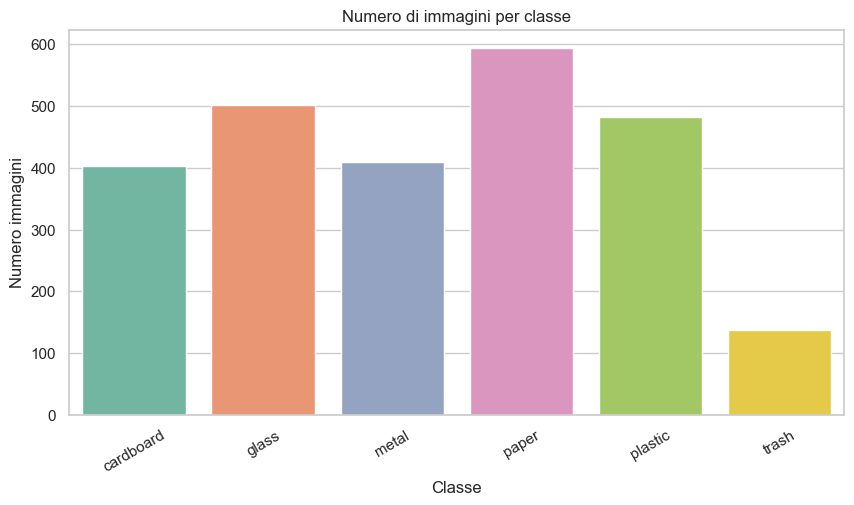

In [6]:
class_distribution = (
    image_catalog["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="image_count")
    .sort_values("class_name")
    .reset_index(drop=True)
)
class_distribution["share_pct"] = 100 * class_distribution["image_count"] / len(image_catalog)
display(class_distribution)

plt.figure(figsize=(10, 5))
sns.barplot(data=class_distribution, x="class_name", y="image_count", palette="Set2")
plt.title("Numero di immagini per classe")
plt.xlabel("Classe")
plt.ylabel("Numero immagini")
plt.xticks(rotation=30)
plt.show()

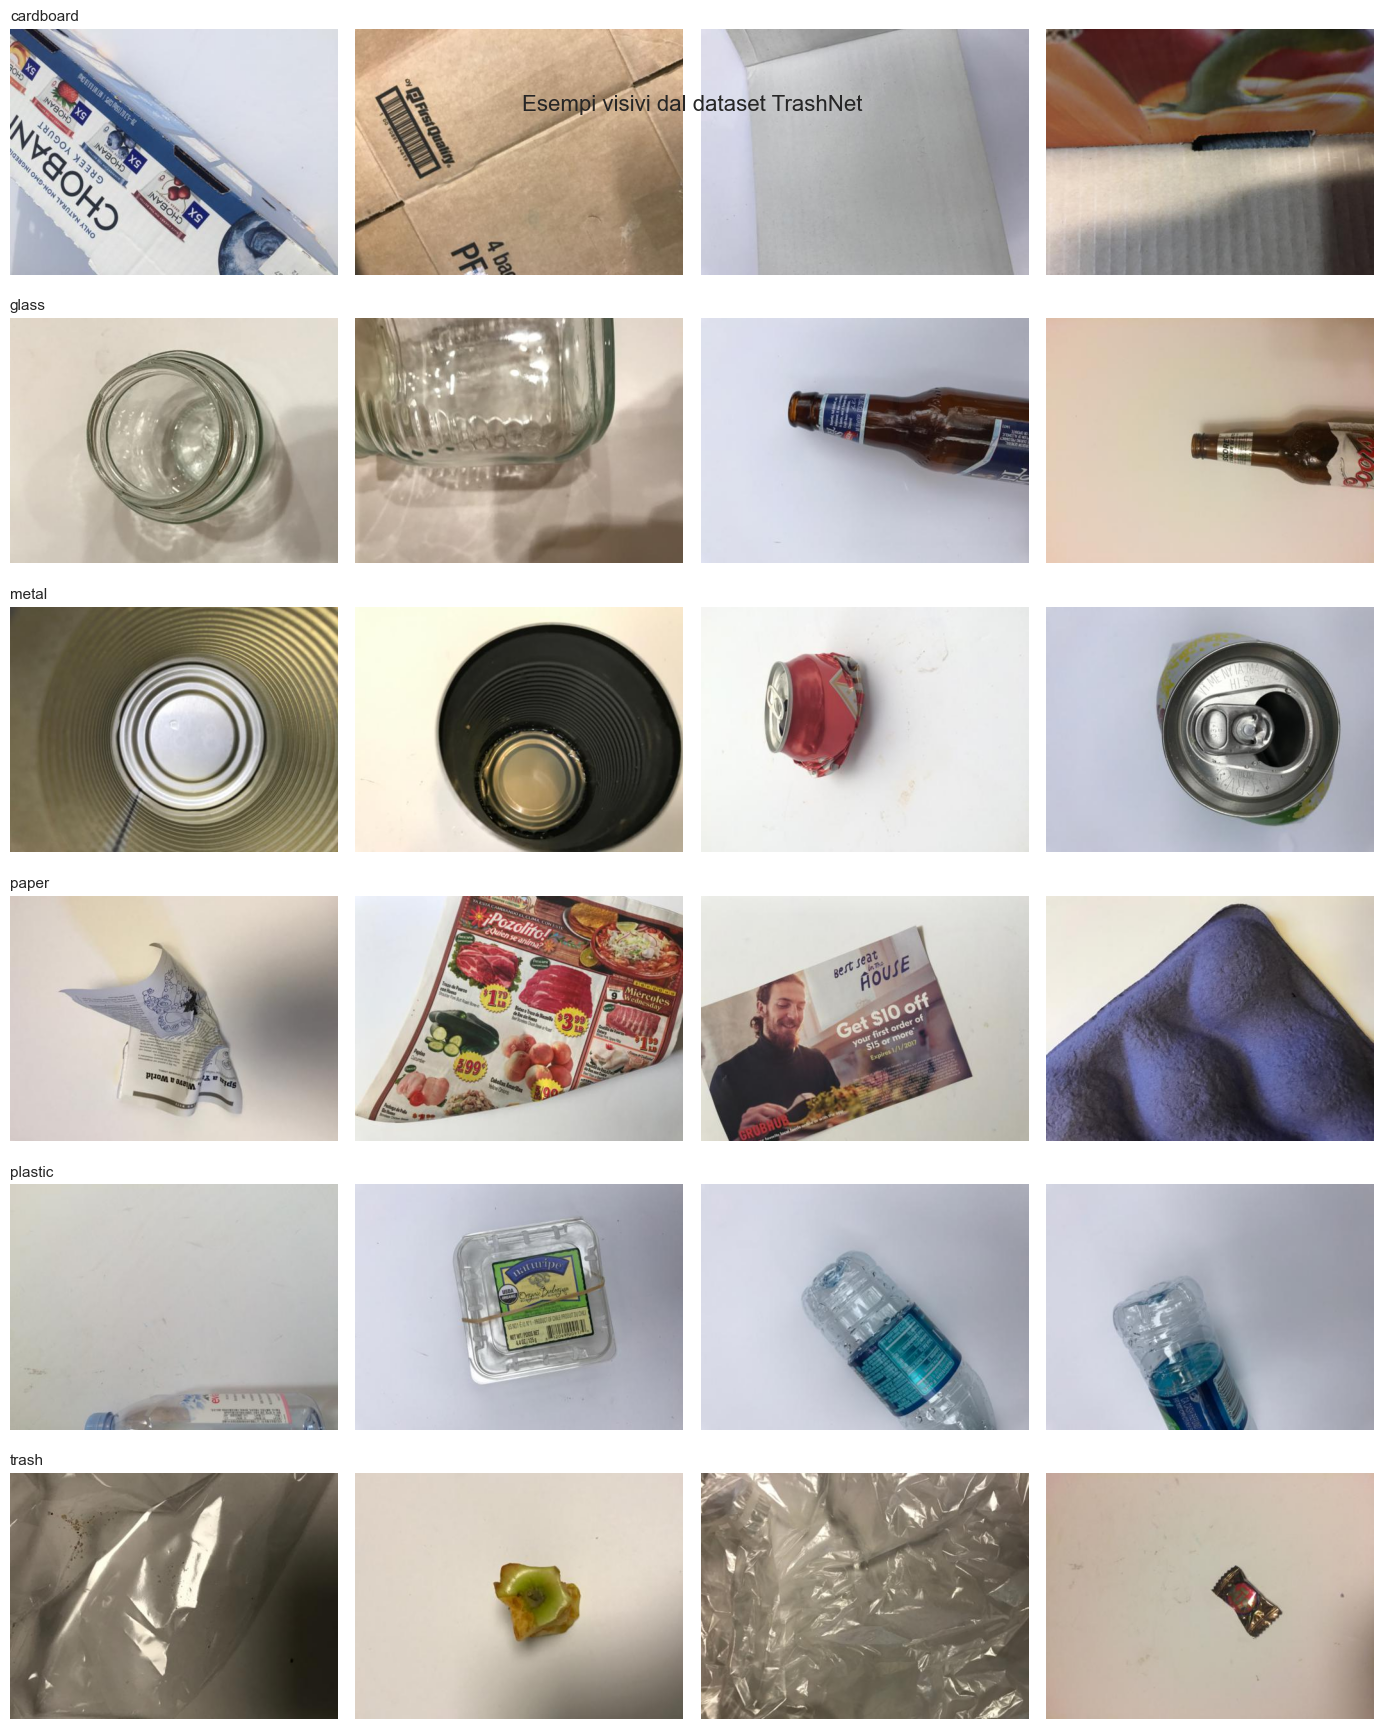

In [7]:
samples_per_class = 4
fig, axes = plt.subplots(NUM_CLASSES, samples_per_class, figsize=(14, 18))

for row_idx, class_name in enumerate(CLASS_NAMES):
    sampled_rows = (
        image_catalog[image_catalog["class_name"] == class_name]
        .sample(n=samples_per_class, random_state=SEED)
        .reset_index(drop=True)
    )
    for col_idx, (_, sample_row) in enumerate(sampled_rows.iterrows()):
        image = load_img(sample_row["filepath"])
        axes[row_idx, col_idx].imshow(image)
        axes[row_idx, col_idx].axis("off")
        if col_idx == 0:
            axes[row_idx, col_idx].set_title(class_name, loc="left", fontsize=11)

plt.suptitle("Esempi visivi dal dataset TrashNet", y=0.92, fontsize=16)
plt.tight_layout()
plt.show()

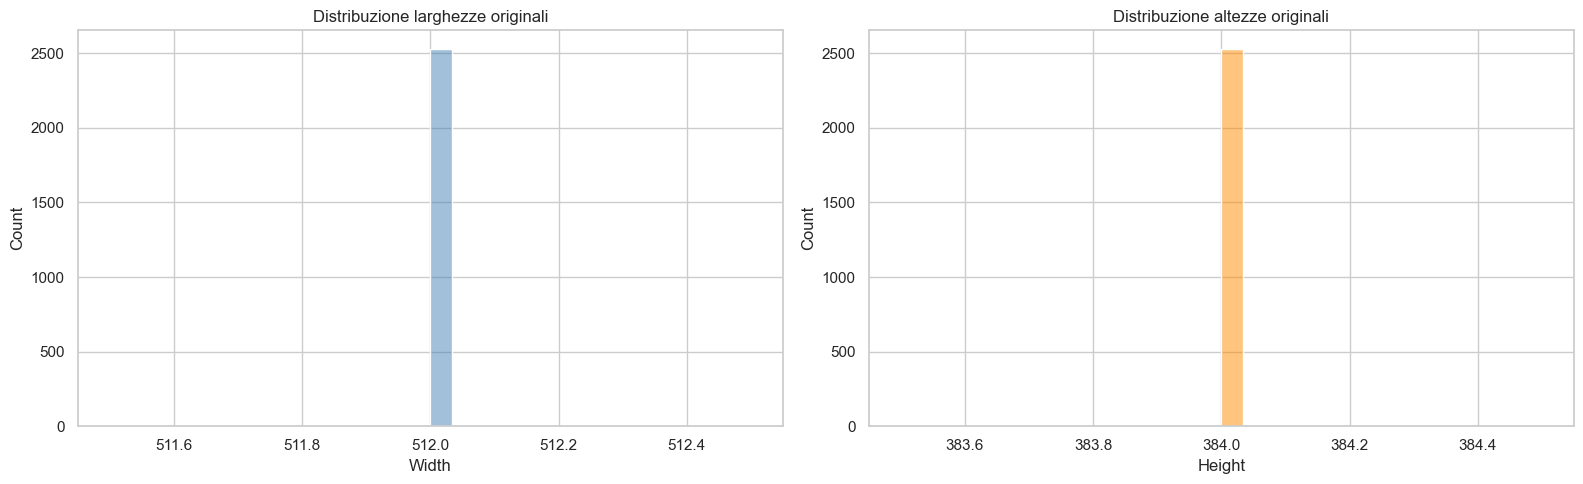

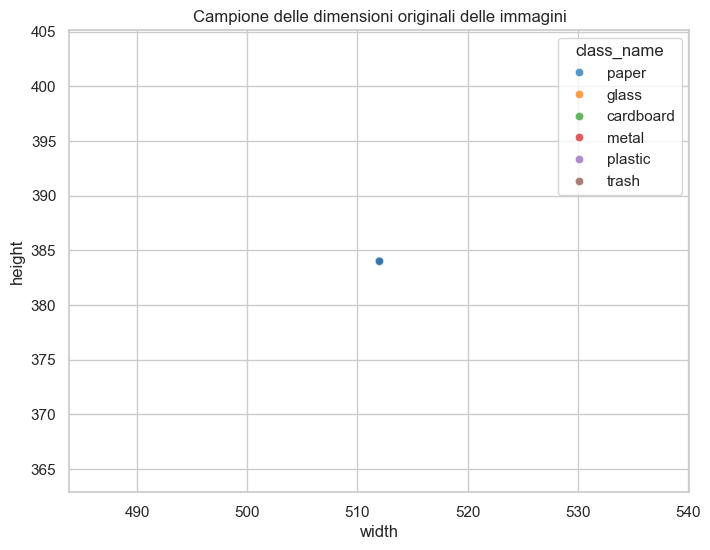

,mean,std,min,max
dimension,,,,
width,512.0,0.0,512.0,512.0
height,384.0,0.0,384.0,384.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data=image_catalog, x="width", bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribuzione larghezze originali")
axes[0].set_xlabel("Width")

sns.histplot(data=image_catalog, x="height", bins=30, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribuzione altezze originali")
axes[1].set_xlabel("Height")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=image_catalog.sample(min(600, len(image_catalog)), random_state=SEED),
    x="width",
    y="height",
    hue="class_name",
    alpha=0.75,
    palette="tab10",
)
plt.title("Campione delle dimensioni originali delle immagini")
plt.show()

display(
    image_catalog[["width", "height"]]
    .describe()
    .T[["mean", "std", "min", "max"]]
    .rename_axis("dimension")
)

,index,class_name,mean,std,min,max
0,0,cardboard,0.584142,0.085954,0.307076,0.848062
1,1,glass,0.666656,0.058136,0.353156,0.839066
2,2,metal,0.619256,0.100084,0.302905,0.879922
3,3,paper,0.643351,0.076383,0.355033,0.793274
4,4,plastic,0.666870,0.058184,0.334464,0.800831
5,5,trash,0.645703,0.068441,0.386926,0.769245


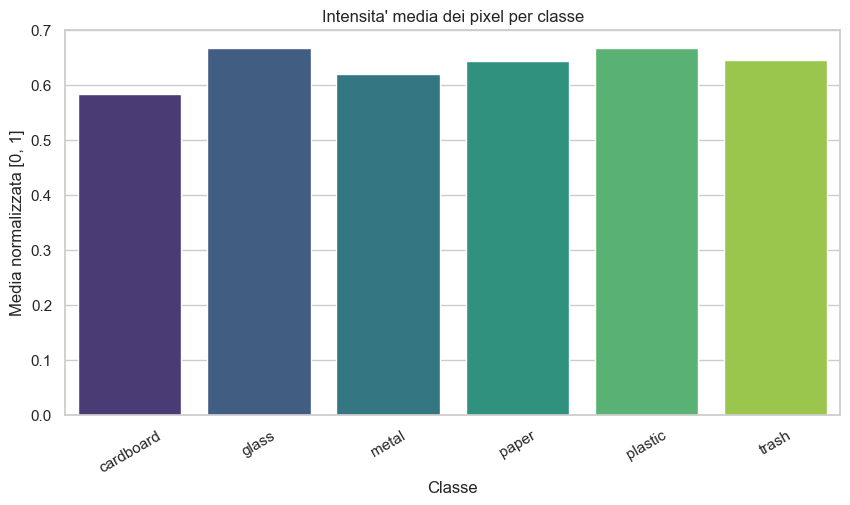

In [12]:
avg_intensity_by_class = (
    image_catalog.groupby("class_name", as_index=False)["avg_pixel_intensity"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)
#avg_intensity_by_class.columns = ["class_name", "mean", "std", "min", "max"]
display(avg_intensity_by_class)

plt.figure(figsize=(10, 5))
sns.barplot(data=avg_intensity_by_class, x="class_name", y="mean", palette="viridis")
plt.title("Intensita' media dei pixel per classe")
plt.ylabel("Media normalizzata [0, 1]")
plt.xlabel("Classe")
plt.xticks(rotation=30)
plt.show()

## 3. Data preprocessing

Requisiti implementati:

- resize a `224x224x3`
- normalizzazione `[0, 1]` per le CNN addestrate da zero
- split stratificato `70 / 15 / 15`
- one-hot encoding delle etichette
- data augmentation con rotazione, flip, shift e zoom

Nota tecnica:

- per il modello **VGG16** usiamo un generatore separato con il preprocessing ImageNet richiesto dai pesi pre-addestrati

In [14]:
train_df, temp_df = train_test_split(
    image_catalog,
    test_size=0.30,
    stratify=image_catalog["class_name"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class_name"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True).copy()
val_df = val_df.reset_index(drop=True).copy()
test_df = test_df.reset_index(drop=True).copy()

split_summary = pd.DataFrame(
    [
        {"split": "train", "n_images": len(train_df), "ratio": len(train_df) / len(image_catalog)},
        {"split": "validation", "n_images": len(val_df), "ratio": len(val_df) / len(image_catalog)},
        {"split": "test", "n_images": len(test_df), "ratio": len(test_df) / len(image_catalog)},
    ]
)
display(split_summary)

y_train_ohe = to_categorical(train_df["label_idx"], num_classes=NUM_CLASSES)
y_val_ohe = to_categorical(val_df["label_idx"], num_classes=NUM_CLASSES)
y_test_ohe = to_categorical(test_df["label_idx"], num_classes=NUM_CLASSES)

print("One-hot train shape:", y_train_ohe.shape)
print("One-hot validation shape:", y_val_ohe.shape)
print("One-hot test shape:", y_test_ohe.shape)

,split,n_images,ratio
0,train,1768,0.699644
1,validation,379,0.149980
2,test,380,0.150376


One-hot train shape: (1768, 6)
One-hot validation shape: (379, 6)
One-hot test shape: (380, 6)


In [15]:
def build_generators(mode="cnn"):
    if mode == "cnn":
        train_datagen = ImageDataGenerator(
            rescale=1.0 / 255.0,
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            zoom_range=0.15,
            horizontal_flip=True,
            fill_mode="nearest",
        )
        eval_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
    elif mode == "vgg16":
        train_datagen = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            zoom_range=0.15,
            horizontal_flip=True,
            fill_mode="nearest",
            preprocessing_function=tf.keras.applications.vgg16.preprocess_input,
        )
        eval_datagen = ImageDataGenerator(
            preprocessing_function=tf.keras.applications.vgg16.preprocess_input
        )
    else:
        raise ValueError(f"Modalita' generator non supportata: {mode}")

    def make_flow(dataframe, datagen, shuffle):
        return datagen.flow_from_dataframe(
            dataframe=dataframe,
            x_col="filepath",
            y_col="class_name",
            target_size=IMAGE_SIZE,
            color_mode="rgb",
            class_mode="categorical",
            classes=CLASS_NAMES,
            batch_size=BATCH_SIZE,
            shuffle=shuffle,
            seed=SEED,
        )

    train_flow = make_flow(train_df, train_datagen, shuffle=True)
    val_flow = make_flow(val_df, eval_datagen, shuffle=False)
    test_flow = make_flow(test_df, eval_datagen, shuffle=False)
    return train_flow, val_flow, test_flow

cnn_train_gen, cnn_val_gen, cnn_test_gen = build_generators(mode="cnn")
print("Class indices generator:", cnn_train_gen.class_indices)

Found 1768 validated image filenames belonging to 6 classes.
Found 379 validated image filenames belonging to 6 classes.
Found 380 validated image filenames belonging to 6 classes.
Class indices generator: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


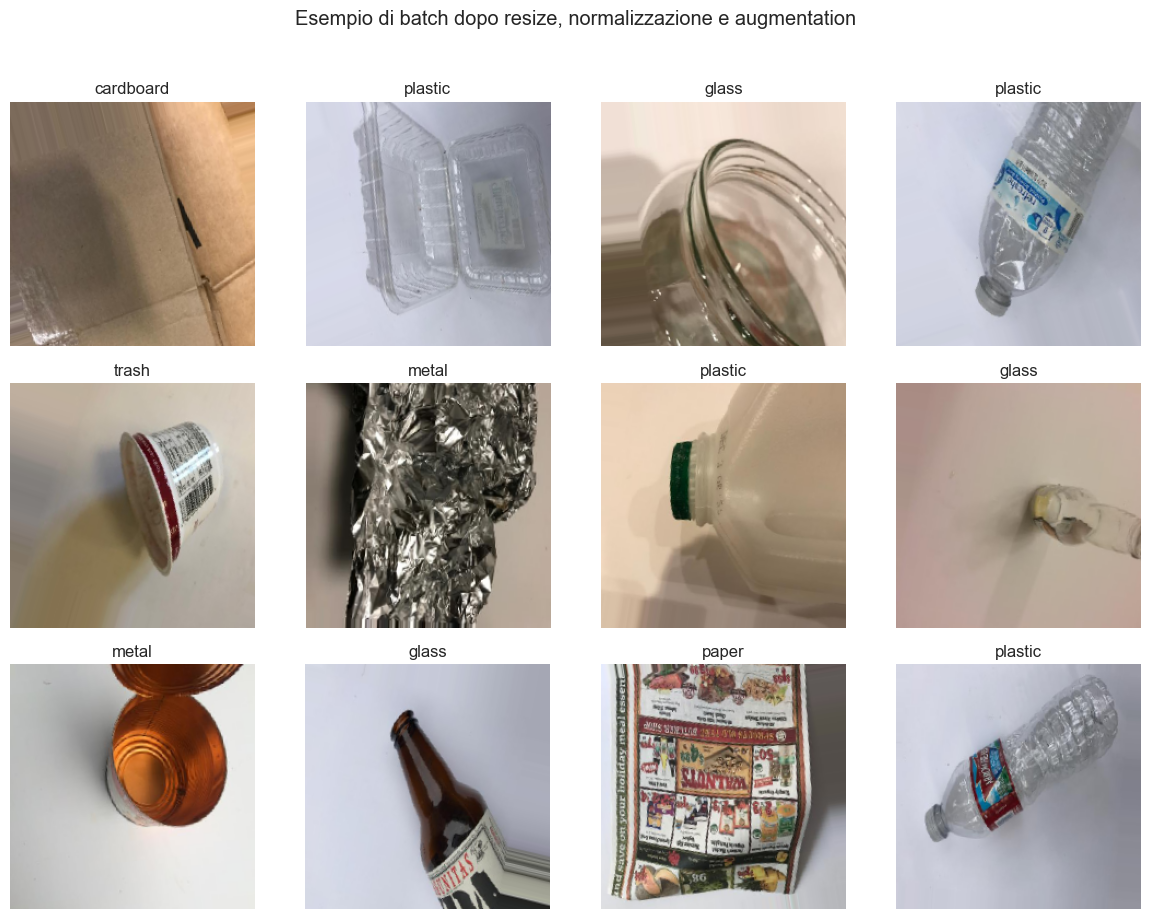

In [16]:
preview_images, preview_labels = next(cnn_train_gen)
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, image_array, label_vector in zip(axes.flat, preview_images[:12], preview_labels[:12]):
    class_name = CLASS_NAMES[int(np.argmax(label_vector))]
    ax.imshow(np.clip(image_array, 0, 1))
    ax.set_title(class_name)
    ax.axis("off")

plt.suptitle("Esempio di batch dopo resize, normalizzazione e augmentation", y=1.02)
plt.tight_layout()
plt.show()

## 4. Modeling

Costruiamo e addestriamo tre modelli:

1. **CNN Baseline**: 2 blocchi `Conv2D + MaxPool`
2. **Improved CNN**: 3 blocchi con `BatchNormalization` e `Dropout`
3. **Transfer Learning con VGG16**: fase frozen + fine-tuning finale

In [17]:
def build_baseline_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    model = models.Sequential(
        [
            layers.Input(shape=input_shape),
            layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Flatten(),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.30),
            layers.Dense(num_classes, activation="softmax"),
        ],
        name="cnn_baseline",
    )
    return model

def build_improved_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Conv2D(64, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs, name="cnn_improved")

def build_transfer_vgg16(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    base_model = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="transfer_vgg16")
    return model, base_model

baseline_model = build_baseline_cnn()
improved_model = build_improved_cnn()
transfer_model, transfer_base_model = build_transfer_vgg16()

baseline_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,710,406 (98.08 MB)

 Trainable params: 25,710,406 (98.08 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
def make_callbacks(model_name):
    checkpoint_path = ARTIFACTS_DIR / f"{model_name}.keras"
    return [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
        callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
    ]

def compile_model(model, learning_rate):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def evaluate_generator(model, generator, split_name, model_name):
    generator.reset()
    probabilities = model.predict(generator, verbose=0)
    predicted_idx = np.argmax(probabilities, axis=1)
    true_idx = generator.classes

    metrics = {
        "model_name": model_name,
        "split": split_name,
        "accuracy": accuracy_score(true_idx, predicted_idx),
        "macro_f1": f1_score(true_idx, predicted_idx, average="macro"),
    }
    return metrics

def plot_training_history(history, title):
    history_frame = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    history_frame[["accuracy", "val_accuracy"]].plot(ax=axes[0], marker="o")
    axes[0].set_title(f"{title} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")

    history_frame[["loss", "val_loss"]].plot(ax=axes[1], marker="o")
    axes[1].set_title(f"{title} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")

    plt.tight_layout()
    plt.show()

def combine_histories(history_a, history_b):
    combined = {}
    for key in history_a.history.keys():
        combined[key] = history_a.history.get(key, []) + history_b.history.get(key, [])
    return combined

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["label_idx"],
)
class_weight_map = {index: float(weight) for index, weight in enumerate(class_weight_values)}
class_weight_map

{0: 1.044917257683215,
 1: 0.8419047619047619,
 2: 1.0267131242740999,
 3: 0.7083333333333334,
 4: 0.874381800197824,
 5: 3.0694444444444446}

Epoch 1/12
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.2045 - loss: 6.1289
Epoch 1: val_loss improved from None to 1.55034, saving model to c:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\05_classificazione_rifiuti\cnn_baseline.keras

Epoch 1: finished saving model to c:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\05_classificazione_rifiuti\cnn_baseline.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 475ms/step - accuracy: 0.2415 - loss: 3.2117 - val_accuracy: 0.3615 - val_loss: 1.5503 - learning_rate: 0.0010
Epoch 2/12
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.3610 - loss: 1.5891
Epoch 2: val_loss improved from 1.55034 to 1.43895, saving model to c:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\05_classificazione_rifiuti\cnn_baseline.keras

Epoch 2: finished saving model to c:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\05_classificazione_rifiuti\cnn_baseline.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 414ms/step - accuracy: 0.356

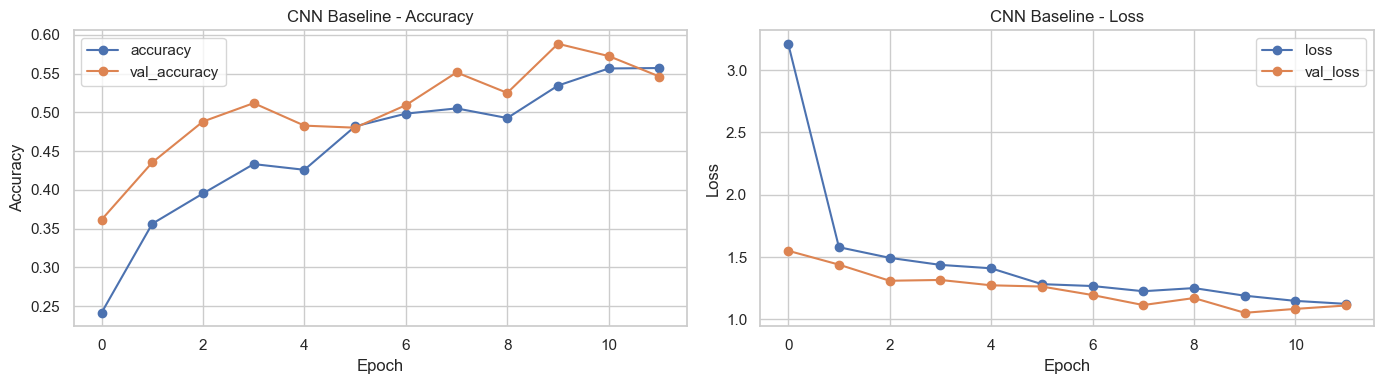

In [19]:
trained_models = {}
history_store = {}
metrics_records = []
preprocessing_by_model = {}

baseline_model = compile_model(build_baseline_cnn(), learning_rate=1e-3)
baseline_history = baseline_model.fit(
    cnn_train_gen,
    validation_data=cnn_val_gen,
    epochs=12,
    callbacks=make_callbacks("cnn_baseline"),
    class_weight=class_weight_map,
    verbose=1,
)
baseline_model = tf.keras.models.load_model(ARTIFACTS_DIR / "cnn_baseline.keras")

history_store["CNN Baseline"] = baseline_history
trained_models["CNN Baseline"] = baseline_model
preprocessing_by_model["CNN Baseline"] = "cnn"
metrics_records.append(evaluate_generator(baseline_model, cnn_val_gen, "validation", "CNN Baseline"))
metrics_records.append(evaluate_generator(baseline_model, cnn_test_gen, "test", "CNN Baseline"))

plot_training_history(baseline_history, "CNN Baseline")

Epoch 1/12
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.2112 - loss: 47.7318
Epoch 1: val_loss improved from None to 1.79329, saving model to c:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\05_classificazione_rifiuti\cnn_improved.keras

Epoch 1: finished saving model to c:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\05_classificazione_rifiuti\cnn_improved.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 48s 812ms/step - accuracy: 0.1872 - loss: 21.4062 - val_accuracy: 0.0554 - val_loss: 1.7933 - learning_rate: 0.0010
Epoch 2/12
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.0710 - loss: 1.8103
Epoch 2: val_loss did not improve from 1.79329
56/56 ━━━━━━━━━━━━━━━━━━━━ 47s 833ms/step - accuracy: 0.0747 - loss: 1.7818 - val_accuracy: 0.0554 - val_loss: 1.7935 - learning_rate: 0.0010
Epoch 3/12
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.1127 - loss: 1.7133
Epoch 3: val_loss improved from 1.79329 to 1.78726, saving model to c:\Users\samue\Desktop\Machin

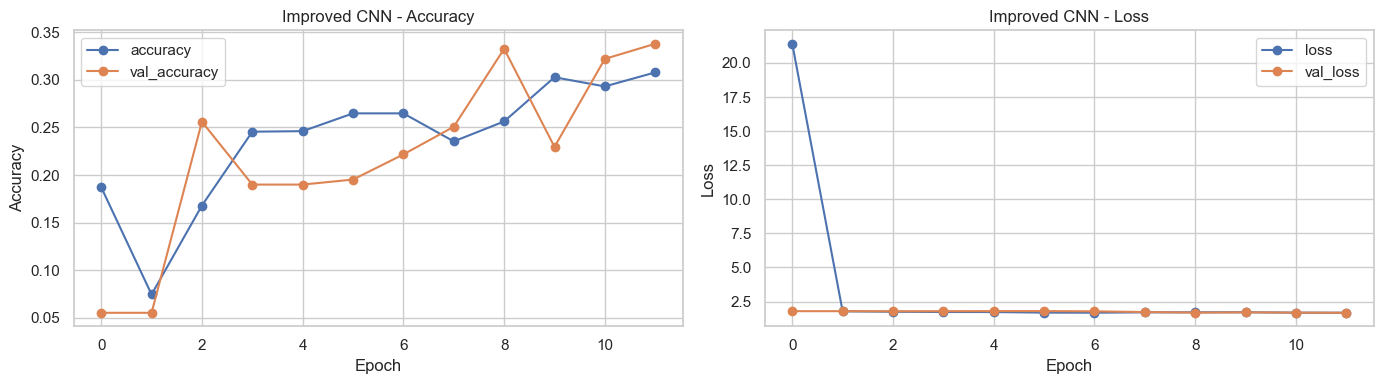

In [20]:
improved_model = compile_model(build_improved_cnn(), learning_rate=1e-3)
improved_history = improved_model.fit(
    cnn_train_gen,
    validation_data=cnn_val_gen,
    epochs=12,
    callbacks=make_callbacks("cnn_improved"),
    class_weight=class_weight_map,
    verbose=1,
)
improved_model = tf.keras.models.load_model(ARTIFACTS_DIR / "cnn_improved.keras")

history_store["Improved CNN"] = improved_history
trained_models["Improved CNN"] = improved_model
preprocessing_by_model["Improved CNN"] = "cnn"
metrics_records.append(evaluate_generator(improved_model, cnn_val_gen, "validation", "Improved CNN"))
metrics_records.append(evaluate_generator(improved_model, cnn_test_gen, "test", "Improved CNN"))

plot_training_history(improved_history, "Improved CNN")

In [21]:
vgg_train_gen, vgg_val_gen, vgg_test_gen = build_generators(mode="vgg16")

transfer_model, transfer_base_model = build_transfer_vgg16()
transfer_model = compile_model(transfer_model, learning_rate=1e-4)

transfer_history_frozen = transfer_model.fit(
    vgg_train_gen,
    validation_data=vgg_val_gen,
    epochs=10,
    callbacks=make_callbacks("transfer_vgg16_frozen"),
    class_weight=class_weight_map,
    verbose=1,
)
transfer_model = tf.keras.models.load_model(ARTIFACTS_DIR / "transfer_vgg16_frozen.keras")

Found 1768 validated image filenames belonging to 6 classes.
Found 379 validated image filenames belonging to 6 classes.
Found 380 validated image filenames belonging to 6 classes.
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2057 - loss: 4.1010
Epoch 1: val_loss improved from None to 1.65657, saving model to c:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\05_classificazione_rifiuti\transfer_vgg16_frozen.keras

Epoch 1: finished saving model to c:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\05_classificazione_rifiuti\transfer_vgg16_frozen.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.2443 - loss: 3.6689 - val_accuracy: 0.4591 - val_loss: 1.6566 - learning_rate: 1.0000e-04
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3811 - loss: 2.5275
Epoch 2: val_loss improved from 1.65657 to 1.19305, saving model to c:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\05_classificazione_rifiuti\transfer_vgg16_frozen.ke

In [ ]:
vgg_backbone = transfer_model.get_layer("vgg16")

for layer in vgg_backbone.layers[:-4]:
    layer.trainable = False
for layer in vgg_backbone.layers[-4:]:
    layer.trainable = True

transfer_model = compile_model(transfer_model, learning_rate=1e-5)

transfer_history_finetune = transfer_model.fit(
    vgg_train_gen,
    validation_data=vgg_val_gen,
    epochs=8,
    callbacks=make_callbacks("transfer_vgg16_finetuned"),
    class_weight=class_weight_map,
    verbose=1,
)
transfer_model = tf.keras.models.load_model(ARTIFACTS_DIR / "transfer_vgg16_finetuned.keras")

combined_transfer_history = combine_histories(transfer_history_frozen, transfer_history_finetune)
transfer_history_full = type("HistoryWrapper", (), {"history": combined_transfer_history})()

history_store["Transfer Learning VGG16"] = transfer_history_full
trained_models["Transfer Learning VGG16"] = transfer_model
preprocessing_by_model["Transfer Learning VGG16"] = "vgg16"
metrics_records.append(evaluate_generator(transfer_model, vgg_val_gen, "validation", "Transfer Learning VGG16"))
metrics_records.append(evaluate_generator(transfer_model, vgg_test_gen, "test", "Transfer Learning VGG16"))

plot_training_history(transfer_history_full, "Transfer Learning VGG16")

Epoch 1/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7565 - loss: 0.6972
Epoch 1: val_loss improved from None to 0.65021, saving model to c:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\05_classificazione_rifiuti\transfer_vgg16_finetuned.keras

Epoch 1: finished saving model to c:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\05_classificazione_rifiuti\transfer_vgg16_finetuned.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.7523 - loss: 0.7196 - val_accuracy: 0.7546 - val_loss: 0.6502 - learning_rate: 1.0000e-05
Epoch 2/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7781 - loss: 0.6555
Epoch 2: val_loss improved from 0.65021 to 0.62818, saving model to c:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\05_classificazione_rifiuti\transfer_vgg16_finetuned.keras

Epoch 2: finished saving model to c:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\05_classificazione_rifiuti\transfer_vgg16_finetuned.keras
56/56 ━━━━━━━━━━━

In [ ]:
metrics_df = pd.DataFrame(metrics_records).sort_values(["split", "macro_f1", "accuracy"], ascending=[True, False, False])
display(metrics_df.style.format({"accuracy": "{:.4f}", "macro_f1": "{:.4f}"}))

validation_ranking = metrics_df[metrics_df["split"] == "validation"].sort_values(
    ["macro_f1", "accuracy"], ascending=False
)
best_model_name = validation_ranking.iloc[0]["model_name"]
best_model = trained_models[best_model_name]
best_preprocessing = preprocessing_by_model[best_model_name]

print("Miglior modello selezionato sulla validation macro F1:", best_model_name)

if best_preprocessing == "vgg16":
    best_test_generator = vgg_test_gen
else:
    best_test_generator = cnn_test_gen

final_test_metrics = metrics_df[
    (metrics_df["split"] == "test") & (metrics_df["model_name"] == best_model_name)
].iloc[0]

final_summary = pd.DataFrame(
    [
        {
            "metric": "Accuracy",
            "value": final_test_metrics["accuracy"],
            "target": TARGET_ACCURACY,
            "target_reached": final_test_metrics["accuracy"] >= TARGET_ACCURACY,
        },
        {
            "metric": "Macro F1",
            "value": final_test_metrics["macro_f1"],
            "target": TARGET_MACRO_F1,
            "target_reached": final_test_metrics["macro_f1"] >= TARGET_MACRO_F1,
        },
    ]
)
display(final_summary.style.format({"value": "{:.4f}", "target": "{:.2f}"}))

## 5. Evaluation ed error analysis

Per il miglior modello:

- confusion matrix normalizzata
- coppie di classi piu' confuse
- esempi di predizioni corrette e errate con confidence score

In [ ]:
best_test_generator.reset()
test_probabilities = best_model.predict(best_test_generator, verbose=0)
test_pred_idx = np.argmax(test_probabilities, axis=1)
test_true_idx = best_test_generator.classes
test_confidences = test_probabilities.max(axis=1)

print("Classification report - best model on test set")
print(
    classification_report(
        test_true_idx,
        test_pred_idx,
        target_names=CLASS_NAMES,
        digits=4,
    )
)

conf_matrix = confusion_matrix(test_true_idx, test_pred_idx)
conf_matrix_norm = conf_matrix.astype("float") / conf_matrix.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title(f"Confusion matrix normalizzata - {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

In [ ]:
confusion_rows = []
true_class_support = conf_matrix.sum(axis=1)

for true_idx, true_label in enumerate(CLASS_NAMES):
    for pred_idx, pred_label in enumerate(CLASS_NAMES):
        if true_idx == pred_idx:
            continue
        if conf_matrix[true_idx, pred_idx] == 0:
            continue

        confusion_rows.append(
            {
                "true_class": true_label,
                "predicted_as": pred_label,
                "count": int(conf_matrix[true_idx, pred_idx]),
                "pct_within_true_class": conf_matrix[true_idx, pred_idx] / true_class_support[true_idx],
            }
        )

confusion_pairs_df = pd.DataFrame(confusion_rows).sort_values(
    ["count", "pct_within_true_class"], ascending=False
)
display(confusion_pairs_df.head(10).style.format({"pct_within_true_class": "{:.2%}"}))

In [ ]:
test_results_df = test_df.copy().reset_index(drop=True)
test_results_df["true_label"] = [INDEX_TO_LABEL[index] for index in test_true_idx]
test_results_df["predicted_label"] = [INDEX_TO_LABEL[index] for index in test_pred_idx]
test_results_df["confidence"] = test_confidences
test_results_df["correct"] = test_results_df["true_label"] == test_results_df["predicted_label"]
display(test_results_df.head())

def plot_prediction_examples(results_df, only_correct=True, n_examples=9):
    subset = results_df[results_df["correct"] == only_correct].copy()
    if subset.empty:
        print("Nessun esempio disponibile per questo filtro.")
        return

    if only_correct:
        subset = subset.sort_values("confidence", ascending=False).head(n_examples)
        title = "Predizioni corrette piu' sicure"
    else:
        subset = subset.sort_values("confidence", ascending=False).head(n_examples)
        title = "Errori con confidence piu' alta"

    n_examples = min(n_examples, len(subset))
    n_cols = 3
    n_rows = int(np.ceil(n_examples / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, (_, row) in zip(axes, subset.iterrows()):
        image = load_img(row["filepath"], target_size=IMAGE_SIZE)
        ax.imshow(image)
        ax.set_title(
            (
                f"true: {row['true_label']}\n"
                f"pred: {row['predicted_label']}\n"
                f"conf: {row['confidence']:.3f}"
            ),
            fontsize=10,
        )
        ax.axis("off")

    for ax in axes[n_examples:]:
        ax.axis("off")

    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

plot_prediction_examples(test_results_df, only_correct=True, n_examples=9)
plot_prediction_examples(test_results_df, only_correct=False, n_examples=9)

## 6. Deployment

Salviamo:

- il miglior modello finale in formato `.h5`
- un file metadata `.json`
- la funzione `classifica_rifiuto(model, image_path)`

In [ ]:
FINAL_MODEL_PATH = ARTIFACTS_DIR / "trashnet_best_model.h5"
FINAL_METADATA_PATH = ARTIFACTS_DIR / "trashnet_best_model_metadata.json"

def classifica_rifiuto(model, image_path):
    image = load_img(image_path, target_size=IMAGE_SIZE)
    image_array = img_to_array(image).astype("float32")
    batch = np.expand_dims(image_array, axis=0)

    if "vgg" in model.name.lower():
        batch = tf.keras.applications.vgg16.preprocess_input(batch.copy())
    else:
        batch = batch / 255.0

    probabilities = model.predict(batch, verbose=0)[0]
    predicted_idx = int(np.argmax(probabilities))
    return {
        "predicted_class": INDEX_TO_LABEL[predicted_idx],
        "predicted_index": predicted_idx,
        "confidence": float(probabilities[predicted_idx]),
        "class_probabilities": {
            label: float(probability) for label, probability in zip(CLASS_NAMES, probabilities)
        },
    }

best_model.save(FINAL_MODEL_PATH)

metadata = {
    "project": "05_classificazione_rifiuti",
    "dataset": "TrashNet (garbage-classification)",
    "class_names": CLASS_NAMES,
    "num_classes": NUM_CLASSES,
    "image_size": list(IMAGE_SIZE),
    "best_model_name": best_model_name,
    "best_model_internal_name": best_model.name,
    "preprocessing_mode": best_preprocessing,
    "target_metrics": {
        "accuracy": TARGET_ACCURACY,
        "macro_f1": TARGET_MACRO_F1,
    },
    "test_metrics": {
        "accuracy": float(final_test_metrics["accuracy"]),
        "macro_f1": float(final_test_metrics["macro_f1"]),
    },
    "class_distribution": class_distribution.to_dict(orient="records"),
    "label_to_index": LABEL_TO_INDEX,
}

with open(FINAL_METADATA_PATH, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print("Best model saved to:", FINAL_MODEL_PATH.resolve())
print("Metadata saved to:", FINAL_METADATA_PATH.resolve())

deployment_example = classifica_rifiuto(best_model, test_df.loc[0, "filepath"])
deployment_example